# Activation Functions (PyTorch)

Activation functions introduce non-linearity between layers, which is what lets an
[`ANN`](../02_ANN) learn non-linear decision boundaries instead of just a linear
mapping. We first plot the three most common activations, then train the **same**
64->32->10 MLP on the `sklearn` digits dataset three times — once per activation —
to see how the choice affects training.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)

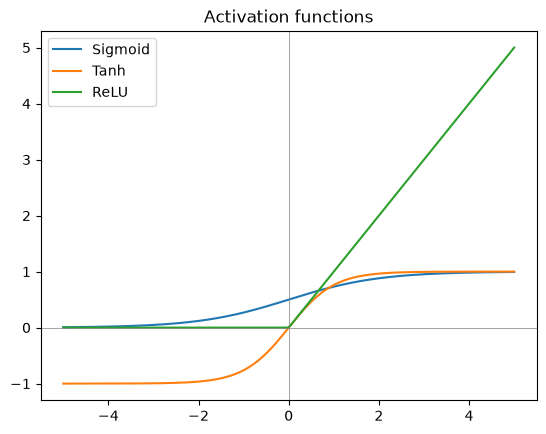

In [2]:
x = torch.linspace(-5, 5, 200)
fig, ax = plt.subplots()
ax.plot(x, torch.sigmoid(x), label="Sigmoid")
ax.plot(x, torch.tanh(x), label="Tanh")
ax.plot(x, torch.relu(x), label="ReLU")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.legend()
ax.set_title("Activation functions")
plt.show()

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train = torch.tensor(scaler.transform(X_train), dtype=torch.float32)
X_test = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


def make_model(activation):
    return nn.Sequential(
        nn.Linear(64, 64), activation(),
        nn.Linear(64, 32), activation(),
        nn.Linear(32, 10),
    )


activations = {"Sigmoid": nn.Sigmoid, "Tanh": nn.Tanh, "ReLU": nn.ReLU}

In [4]:
results = {}
for name, act in activations.items():
    torch.manual_seed(0)
    model = make_model(act)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(60):
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        acc = (model(X_test).argmax(dim=1) == y_test).float().mean().item()

    results[name] = {"losses": losses, "accuracy": acc}
    print(f"{name:8s} final loss {losses[-1]:.4f}  test accuracy {acc:.3f}")

Sigmoid  final loss 0.1338  test accuracy 0.964
Tanh     final loss 0.0140  test accuracy 0.964
ReLU     final loss 0.0011  test accuracy 0.964


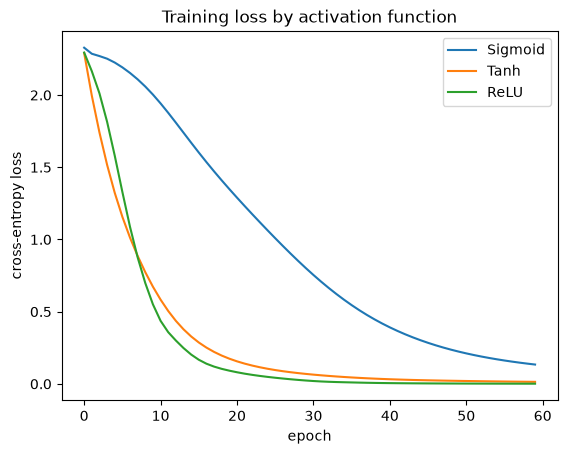

In [5]:
plt.figure()
for name, r in results.items():
    plt.plot(r["losses"], label=name)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Training loss by activation function")
plt.legend()
plt.show()